# Reto de la Semanan 4: Optimización con Regresión Logística

Este cuaderno implementa la solución al problema de minimizacion para encontrar los parámetros óptimos, siendo una manera de encontrar los parametros optimos para un modelo regresión logística, se resolvio basándose en el documento proporcionado y el conjunto de datos breastCancer.

In [2]:
#  Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [3]:
# importamos los datos
ruta_archivo = 'BreastCancer.csv'
data = pd.read_csv(ruta_archivo)

In [4]:
# Extraemos los valores de los datos en la matriz X
X = data[['radius_mean', 'smoothness_mean']].values

# Extraemos la variable objetivo
t = data['pronostic'].values

Z = np.hstack((X, np.ones((X.shape[0], 1))))

m = Z.shape[0] # # entrenamiento
n = Z.shape[1] # # caracteristicas

print(f"\nDimensión de Z (características + intercepto): {Z.shape}")
print(f"Dimensión de t (objetivo): {t.shape}")


Dimensión de Z (características + intercepto): (469, 3)
Dimensión de t (objetivo): (469,)


In [5]:
def sigmoid(v):
    """
    funcion sigmoide.
    """
    return 1 / (1 + np.exp(-v))

In [6]:
def loss_function(w, Z, t):
    """
    funcion de perdida de la regresion logistica
    """
    y = sigmoid(Z @ w) 
    epsilon = 1e-15 
    loss = -np.mean(t * np.log(y + epsilon) + (1 - t) * np.log(1 - y + epsilon))
    return loss

In [7]:
def gradient(w, Z, t):
    """
    Gradiente de la function de perdida de la regresion logistica 
    """
    y = sigmoid(Z @ w)
    grad = (1/m) * Z.T @ (y - t) 
    return grad

In [8]:
def hessian(w, Z, t):
    """
    Hessiana de la funcion de perdida de regresion logistica.
    """
    y = sigmoid(Z @ w)
    S = np.diag(y * (1 - y))
    hess = (1/m) * Z.T @ S @ Z 
    return hess

In [9]:
w_history = []

# Función de callback para almacenar el w actual
def callback_function(w):
    """
    Función de callback para scipy.optimize.minimize para almacenar w en cada iteración.
    """
    w_history.append(np.copy(w)) # Agregar una copia de w

In [10]:
initial_w = np.zeros(n)

# Usar minimize para encontrar el w óptimo, con el callback
# Usando el método 'BFGS' que también utiliza información del gradiente y es adecuado para este problema
result = minimize(loss_function, initial_w, args=(Z, t), method='BFGS', jac=gradient, callback=callback_function)

# Extraer el w óptimo
optimal_w = result.x

print(f"\nResultado de la Optimización:")
print(f"Éxito: {result.success}")
print(f"Mensaje: {result.message}")
print(f"Número de iteraciones: {result.nit}")
print(f"w óptimo: {optimal_w}")

# Asegurar que el w óptimo final también esté incluido en el historial
if not np.array_equal(w_history[-1], optimal_w):
     w_history.append(np.copy(optimal_w))


Resultado de la Optimización:
Éxito: True
Mensaje: Optimization terminated successfully.
Número de iteraciones: 20
w óptimo: [5.35905314 1.64119534 0.24430282]


In [11]:
loss_history = [loss_function(w, Z, t) for w in w_history]
gradient_norm_history = [np.linalg.norm(gradient(w, Z, t)) for w in w_history]
iterations = range(len(w_history))

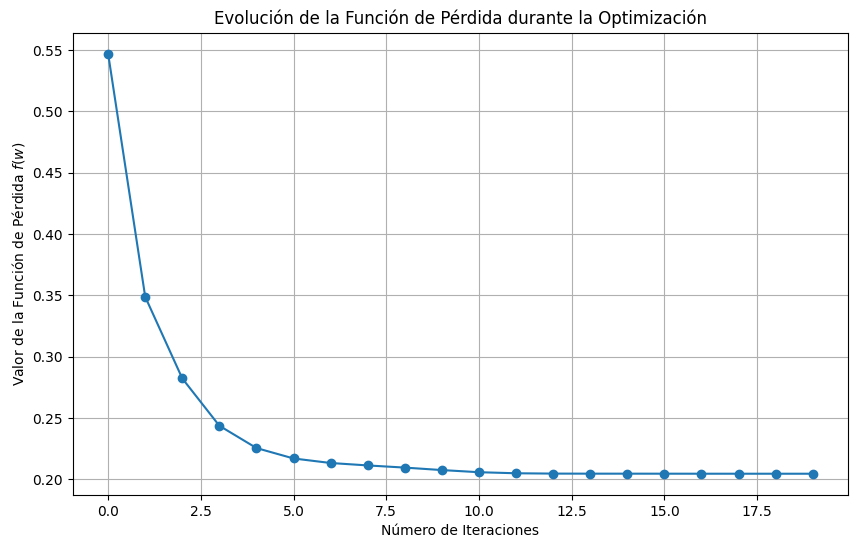

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(iterations, loss_history, marker='o', linestyle='-')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Valor de la Función de Pérdida $f(w)$')
plt.title('Evolución de la Función de Pérdida durante la Optimización')
plt.grid(True)
plt.show()

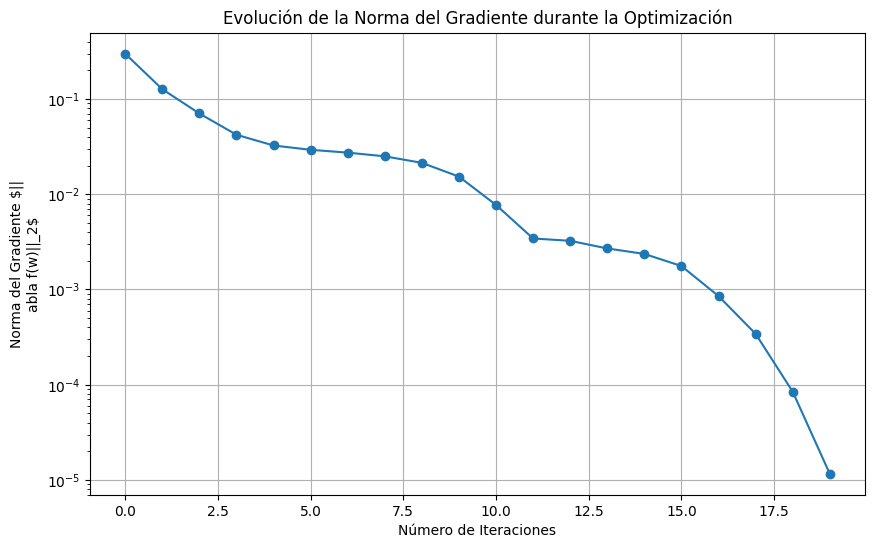

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(iterations, gradient_norm_history, marker='o', linestyle='-')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Norma del Gradiente $||\nabla f(w)||_2$')
plt.title('Evolución de la Norma del Gradiente durante la Optimización')
plt.grid(True)
plt.yscale('log') # Usar escala logarítmica para mejor visualización si la norma decrece rápidamente
plt.show()

In [14]:
hessian_at_optimal_w = hessian(optimal_w, Z, t)
eigenvalues = np.linalg.eigvals(hessian_at_optimal_w)

print(f"\nMatriz Hessiana en w óptimo:\n{hessian_at_optimal_w}")
print(f"\nValores propios de la Hessiana:\n{eigenvalues}")

# Verificar si es positiva semi-definida (todos los valores propios son no negativos)
is_positive_semidefinite = np.all(eigenvalues >= -1e-9) # Permitir pequeños errores numéricos

print(f"\nLa Hessiana es positiva semi-definida (todos los valores propios >= 0): {is_positive_semidefinite}")


Matriz Hessiana en w óptimo:
[[ 0.01005839 -0.01356613 -0.01039176]
 [-0.01356613  0.05477447  0.00994848]
 [-0.01039176  0.00994848  0.06329617]]

Valores propios de la Hessiana:
[0.00529036 0.07401224 0.04882643]

La Hessiana es positiva semi-definida (todos los valores propios >= 0): True


In [15]:
print("\nConclusión:")
if result.success:
    print("El optimizador convergió exitosamente a una solución.")
    print(f"En el punto óptimo encontrado (w = {optimal_w}):")
    print(f"- El gradiente es aproximadamente cero (Norma del gradiente: {gradient_norm_history[-1]:.4e}).")

    if is_positive_semidefinite:
        print("- La matriz Hessiana es positiva semi-definida.")
        print("Dado que la función de pérdida de regresión logística es convexa,")
        print("un punto donde el gradiente es cero y la Hessiana es positiva semi-definida")
        print("corresponde a un mínimo global.")
    else:
        print("- La matriz Hessiana no es positiva semi-definida.")
        print("Esto es inesperado para una función de pérdida convexa y podría indicar")
        print("problemas numéricos o de convergencia.")
else:
    print("El optimizador no convergió exitosamente.")
    print("No se puede concluir sobre la naturaleza de la solución encontrada como minimizador.")


Conclusión:
El optimizador convergió exitosamente a una solución.
En el punto óptimo encontrado (w = [5.35905314 1.64119534 0.24430282]):
- El gradiente es aproximadamente cero (Norma del gradiente: 1.1625e-05).
- La matriz Hessiana es positiva semi-definida.
Dado que la función de pérdida de regresión logística es convexa,
un punto donde el gradiente es cero y la Hessiana es positiva semi-definida
corresponde a un mínimo global.


Se verifica que los valores de w obtenidos a traves de minimize son los mismos que en el taller 4 